### case study question

1)	The attached raw data dictionary stored in raw_data_dic.p  has the below (key, value) pairs :
    a)	stock_prices:  pd.DataFrame: monthly stock prices for  1000 stocks 156 months
    b)	ind_class:  pd.Series  : industry classification of the 1000 stocks; total 10 industries
    c)	mkt_price : pd.Series  : monthly returns for the market factor
    d)	rf_ret : pd.Series : monthly returns on a risk free asset
    e)	stock_mcap: pd.Series : Initial market cap for the 1000 stocks at time 0

2)	Exercises:
    a)	Generate a price momentum signal for each stock, where the signal at time t is the cumulative returns realized by the stock from month t-12 to month t-1 (eg: the signal on the Dec 31st, 2024 would be the cumulative returns realized by stocks from Dec,31st, 2023 to Nov 30th, 2024)

    b)	Starting month 36 (i.e. index 36), build the following monthly rebalanced portfolios. Store the return series in a python dict with the keys as the below portfolio tags. Grading will assume returns on month i are the returns observed over the month i.

        i)	Equal Weighted XS (cross-section) Long-Short Portfolios (tag: eq_wt) :
        (1)	Portfolios which go long (short) the top (bottom) 20% stocks, stocks are equal weighted in the long and short bucket. Each buckets is unit levered.

        ii)	Size adjusted Equal Weighted XS Long Short Portfolios (tag: size_eq_wt):
        (1)	At time t, divide the XS of stocks into large and small cap bucket by the stock market caps using the 50 percentile (median) market cap break points.
        (2)	Build an equal weighted long short portfolio as in i, but this time for each of the large and small bucket
        (3)	The final portfolio is a 50/50 blend of the large and small portfolios

        iii)	Size Adjusted Cap Weighted XS Long Short portfolios (tag: size_cap_wt)
        (1)	Same as ii, but instead of equal weighting stocks within the long and short buckets, calculate portfolio weights using the stock mcaps

        iv)	Beta Adjusted Cap Weighted XS Long Short Portfolios (tag:  beta_cap_wt):
        (1)	Calculate the CAPM beta of each stock for each month t to the market returns, using the rolling 36 month returns
        (2)	Divide the full XS of stocks into high beta and low beta stocks, using the median beta as the break point
        (3)	For each of the high and low beta stocks buckets, form the 20% long and short cap weighted portfolios, similar to iii

        v)	Industry adjusted Equal Weighted XS Long Short portfolios (tag: ind_adj_eq_wt):
        (1)	Using the industry classification provided, calculate the industry de-median-ed signal score
        (2)	Build the equal weighted XS long short portfolios, similar to i, but on the industry adjusted scores

    c)	For the n# portfolios in 2b) generate the following set of stats; store the stats below in a python dict, with the first level of keys being the below the stats tag; while the values being a pd.Series object with index being the portfolios tags in step b above.

        i)	Full sample CAGR; compounded annual growth rates (tag: cagr)
        ii)	Full sample annualized volatility (tag: ann_vol)
        iii)	Full Sample Sharpe Ratios (tag: SR);
        iv)	Maximum drawdown for each portfolios (arithmetic drawdown) (tag: drawdown)
        v)	Maximum rolling 36 month SR (tag: max_rolling_sr)


    d)	Store the final output in a nested dict format as below and cache it as a pickle file with name output_dic.pkl

        output_dic = {
            "ret_dict": #return dictionary from step 2b
            "stats_dict": #stats dictionary from step 2c
        }
        pd.to_pickle(output_dic, "output_dic.pkl")


In [1]:
# sample imports
import pandas as pd
import numpy as np
import scipy as sp

In [2]:
in_dic = pd.read_pickle("pricemom_case_study_raw_data.pkl")

In [3]:
stk_prices = in_dic["stock_prices"]
ind_class = in_dic["ind_class"]
mkt_price = in_dic["mkt_price"]
rf_ret = in_dic["rf_ret"]
init_mkt_cap = in_dic["stock_mcap"]

In [17]:
stk_prices.iloc[:,0].to_frame()

,stk1
0,629.29
1,598.19
2,670.15
3,562.95
4,570.52
...,...
151,2243.04
152,2221.17
153,2416.33
154,2222.25


In [19]:
stk_rets = stk_prices.pct_change()
stk_rets

,stk1,stk2,stk3,stk4,stk5,stk6,stk7,stk8,stk9,stk10,...,stk991,stk992,stk993,stk994,stk995,stk996,stk997,stk998,stk999,stk1000
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-0.049421,0.040599,0.015726,0.018157,-0.034788,0.071130,-0.028312,0.089718,0.089521,0.030628,...,-0.011009,-0.013983,-0.067543,-0.037121,-0.034482,-0.008958,-0.136817,-0.036633,-0.057157,-0.085981
2,0.120296,-0.009298,0.000747,0.065121,0.031429,-0.070334,-0.046088,0.039947,-0.004358,0.150043,...,-0.106707,0.062927,0.006955,-0.036369,-0.061105,-0.004469,0.022988,0.027508,-0.123637,0.194975
3,-0.159964,-0.051020,-0.081664,0.033051,0.009051,-0.005435,0.213913,-0.026761,-0.036648,-0.062135,...,-0.056353,0.231043,0.043134,0.091623,0.033820,0.011264,0.055137,-0.078740,0.006978,0.010755
4,0.013447,-0.045479,-0.102960,-0.041909,-0.146543,-0.009878,-0.110006,-0.008474,0.013405,0.016072,...,0.064789,-0.102762,0.038403,-0.111683,0.023090,-0.033628,-0.079733,-0.044872,-0.105152,-0.027027
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,0.057813,0.265844,-0.018028,0.171800,0.039674,0.025760,-0.004795,-0.039083,0.187566,0.202172,...,0.015342,0.068810,-0.072872,-0.002916,0.083494,0.051709,0.026348,-0.069070,0.010942,0.193160
152,-0.009750,0.130227,-0.051309,0.051760,0.110319,0.137693,0.037344,-0.071425,0.088823,0.081240,...,0.089439,-0.041633,0.148627,0.059778,0.220629,0.021375,-0.040008,0.110479,0.135830,0.063725
153,0.087864,0.069184,0.092122,0.144963,0.308187,0.095636,-0.003964,0.062484,0.076378,0.096577,...,0.059078,-0.046559,-0.044051,-0.153272,0.191189,0.038442,0.020274,0.126798,0.199611,0.062361
154,-0.080320,-0.154974,-0.108829,-0.054666,0.012432,-0.127540,-0.100779,0.122288,0.035248,-0.158626,...,-0.115563,-0.139562,0.171665,-0.075140,-0.024722,-0.083296,-0.024628,-0.068383,-0.042961,0.015224


In [22]:
(1 + stk_rets)

,stk1,stk2,stk3,stk4,stk5,stk6,stk7,stk8,stk9,stk10,...,stk991,stk992,stk993,stk994,stk995,stk996,stk997,stk998,stk999,stk1000
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.950579,1.040599,1.015726,1.018157,0.965212,1.071130,0.971688,1.089718,1.089521,1.030628,...,0.988991,0.986017,0.932457,0.962879,0.965518,0.991042,0.863183,0.963367,0.942843,0.914019
2,1.120296,0.990702,1.000747,1.065121,1.031429,0.929666,0.953912,1.039947,0.995642,1.150043,...,0.893293,1.062927,1.006955,0.963631,0.938895,0.995531,1.022988,1.027508,0.876363,1.194975
3,0.840036,0.948980,0.918336,1.033051,1.009051,0.994565,1.213913,0.973239,0.963352,0.937865,...,0.943647,1.231043,1.043134,1.091623,1.033820,1.011264,1.055137,0.921260,1.006978,1.010755
4,1.013447,0.954521,0.897040,0.958091,0.853457,0.990122,0.889994,0.991526,1.013405,1.016072,...,1.064789,0.897238,1.038403,0.888317,1.023090,0.966372,0.920267,0.955128,0.894848,0.972973
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,1.057813,1.265844,0.981972,1.171800,1.039674,1.025760,0.995205,0.960917,1.187566,1.202172,...,1.015342,1.068810,0.927128,0.997084,1.083494,1.051709,1.026348,0.930930,1.010942,1.193160
152,0.990250,1.130227,0.948691,1.051760,1.110319,1.137693,1.037344,0.928575,1.088823,1.081240,...,1.089439,0.958367,1.148627,1.059778,1.220629,1.021375,0.959992,1.110479,1.135830,1.063725
153,1.087864,1.069184,1.092122,1.144963,1.308187,1.095636,0.996036,1.062484,1.076378,1.096577,...,1.059078,0.953441,0.955949,0.846728,1.191189,1.038442,1.020274,1.126798,1.199611,1.062361
154,0.919680,0.845026,0.891171,0.945334,1.012432,0.872460,0.899221,1.122288,1.035248,0.841374,...,0.884437,0.860438,1.171665,0.924860,0.975278,0.916704,0.975372,0.931617,0.957039,1.015224


In [24]:
(1 + stk_rets).shift(1)

,stk1,stk2,stk3,stk4,stk5,stk6,stk7,stk8,stk9,stk10,...,stk991,stk992,stk993,stk994,stk995,stk996,stk997,stk998,stk999,stk1000
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.950579,1.040599,1.015726,1.018157,0.965212,1.071130,0.971688,1.089718,1.089521,1.030628,...,0.988991,0.986017,0.932457,0.962879,0.965518,0.991042,0.863183,0.963367,0.942843,0.914019
3,1.120296,0.990702,1.000747,1.065121,1.031429,0.929666,0.953912,1.039947,0.995642,1.150043,...,0.893293,1.062927,1.006955,0.963631,0.938895,0.995531,1.022988,1.027508,0.876363,1.194975
4,0.840036,0.948980,0.918336,1.033051,1.009051,0.994565,1.213913,0.973239,0.963352,0.937865,...,0.943647,1.231043,1.043134,1.091623,1.033820,1.011264,1.055137,0.921260,1.006978,1.010755
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,1.094341,1.036121,1.101116,1.081725,1.017611,1.137584,0.996930,0.925144,1.161724,1.217751,...,1.032400,1.166763,1.113408,1.072001,1.017781,1.012448,1.040044,1.014838,0.951125,1.079578
152,1.057813,1.265844,0.981972,1.171800,1.039674,1.025760,0.995205,0.960917,1.187566,1.202172,...,1.015342,1.068810,0.927128,0.997084,1.083494,1.051709,1.026348,0.930930,1.010942,1.193160
153,0.990250,1.130227,0.948691,1.051760,1.110319,1.137693,1.037344,0.928575,1.088823,1.081240,...,1.089439,0.958367,1.148627,1.059778,1.220629,1.021375,0.959992,1.110479,1.135830,1.063725
154,1.087864,1.069184,1.092122,1.144963,1.308187,1.095636,0.996036,1.062484,1.076378,1.096577,...,1.059078,0.953441,0.955949,0.846728,1.191189,1.038442,1.020274,1.126798,1.199611,1.062361


In [27]:
(1 + stk_rets).shift(1).rolling(11).apply(np.prod, raw=True)

,stk1,stk2,stk3,stk4,stk5,stk6,stk7,stk8,stk9,stk10,...,stk991,stk992,stk993,stk994,stk995,stk996,stk997,stk998,stk999,stk1000
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,1.602178,1.332422,0.878609,1.147588,1.387382,0.905912,0.998296,1.080328,1.023289,0.848479,...,0.928061,1.110135,1.209082,1.212452,1.448807,1.248565,1.273248,1.195960,1.043208,0.772075
152,1.485654,1.542318,0.909773,1.304073,1.104021,0.906436,0.968044,0.980409,1.374660,0.992235,...,0.819125,1.236244,1.062773,1.189199,1.490237,1.366867,1.250725,1.080773,1.062176,0.866850
153,1.462451,1.806202,0.839061,1.264069,1.232498,1.067434,1.110111,0.832544,1.490350,1.200904,...,0.859072,1.239513,1.219994,1.351897,1.692862,1.385997,1.257556,1.063813,1.246440,0.836925
154,1.975918,2.116569,1.052718,1.507186,1.864201,1.200729,1.262192,0.860338,1.713564,1.441829,...,0.973126,1.361034,1.277379,1.239666,2.020220,1.342325,1.442005,1.403706,1.563496,1.017242


In [28]:
mom_12_1 = (1 + stk_rets).shift(1).rolling(11).apply(np.prod, raw=True) - 1

mom_12_1.head(20)

,stk1,stk2,stk3,stk4,stk5,stk6,stk7,stk8,stk9,stk10,...,stk991,stk992,stk993,stk994,stk995,stk996,stk997,stk998,stk999,stk1000
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [165]:
mom_12_1.head(20)

,stk1,stk2,stk3,stk4,stk5,stk6,stk7,stk8,stk9,stk10,...,stk991,stk992,stk993,stk994,stk995,stk996,stk997,stk998,stk999,stk1000
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# IMPORTANT NOTE ABOUT MY ASSUMPTION/UNDERSTANDING (PORTFOLIOS ARE DOLLAR-NEUTRAL) (MY WEIGHTS ADD UP TO 0)


My five portfolios are all market dollar-neutral in terms of net capital usage, so all the weights add up to 0. I assumed that was what the problem intended us to do.

But because of this, the monthly returns are all small on average compared to risk free return rates.
Also, the way I computed the Sharpe ratio and max 36-month Sharpe ratio is slightly different. I computed them without subtracting risk free rate, which I thought was more appropriate in this market-neutral setting.

I plotted the cumulative returns in a plot below.

# Part B

## (i)

In [163]:
mom_12_1

,stk1,stk2,stk3,stk4,stk5,stk6,stk7,stk8,stk9,stk10,...,stk991,stk992,stk993,stk994,stk995,stk996,stk997,stk998,stk999,stk1000
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,0.602178,0.332422,-0.121391,0.147588,0.387382,-0.094088,-0.001704,0.080328,0.023289,-0.151521,...,-0.071939,0.110135,0.209082,0.212452,0.448807,0.248565,0.273248,0.195960,0.043208,-0.227925
152,0.485654,0.542318,-0.090227,0.304073,0.104021,-0.093564,-0.031956,-0.019591,0.374660,-0.007765,...,-0.180875,0.236244,0.062773,0.189199,0.490237,0.366867,0.250725,0.080773,0.062176,-0.133150
153,0.462451,0.806202,-0.160939,0.264069,0.232498,0.067434,0.110111,-0.167456,0.490350,0.200904,...,-0.140928,0.239513,0.219994,0.351897,0.692862,0.385997,0.257556,0.063813,0.246440,-0.163075
154,0.975918,1.116569,0.052718,0.507186,0.864201,0.200729,0.262192,-0.139662,0.713564,0.441829,...,-0.026874,0.361034,0.277379,0.239666,1.020220,0.342325,0.442005,0.403706,0.563496,0.017242


In [162]:
ranks = mom_12_1.rank(pct=True, axis=1, method="average")
ranks

,stk1,stk2,stk3,stk4,stk5,stk6,stk7,stk8,stk9,stk10,...,stk991,stk992,stk993,stk994,stk995,stk996,stk997,stk998,stk999,stk1000
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,0.896,0.696,0.126,0.471,0.758,0.155,0.274,0.382,0.310,0.099,...,0.185,0.422,0.543,0.548,0.805,0.597,0.620,0.524,0.326,0.050
152,0.844,0.880,0.159,0.691,0.411,0.156,0.237,0.258,0.749,0.273,...,0.077,0.613,0.363,0.545,0.847,0.742,0.627,0.383,0.361,0.119
153,0.764,0.943,0.065,0.566,0.523,0.281,0.347,0.062,0.791,0.475,...,0.080,0.534,0.505,0.647,0.907,0.681,0.556,0.277,0.542,0.064
154,0.912,0.956,0.139,0.622,0.866,0.274,0.342,0.028,0.786,0.550,...,0.077,0.468,0.365,0.314,0.931,0.453,0.551,0.519,0.672,0.112


In [ ]:
#sum weights row-wise
weights.sum(axis=1)


0      0.000000e+00
1      0.000000e+00
2      0.000000e+00
3      0.000000e+00
4      0.000000e+00
           ...     
151    0.000000e+00
152    1.387779e-17
153    0.000000e+00
154    0.000000e+00
155    1.387779e-17
Length: 156, dtype: float64

In [180]:
import pandas as pd
import numpy as np


ranks = mom_12_1.rank(pct=True, axis=1, method="average")

long_mask  = ranks > 0.80
short_mask = ranks <= 0.20

n_long  = long_mask.sum(axis=1)
n_short = short_mask.sum(axis=1)

w_long  = long_mask.div(n_long.replace(0, np.nan), axis=0) 
w_short = -short_mask.div(n_short.replace(0, np.nan), axis=0)


valid_rets = stk_rets.notna()
w_long  = w_long.where(valid_rets, 0.0)
w_short = w_short.where(valid_rets, 0.0)


weights = (w_long.fillna(0.0) + w_short.fillna(0.0))
eq_wt_series = (weights * stk_rets).sum(axis=1)

# starting from the monthh 36
eq_wt_series.loc[eq_wt_series.index[:36]] = np.nan
eq_wt_series.name = "eq_wt"

eq_wt_series.tail(10)

146    0.003076
147   -0.002091
148   -0.001580
149    0.005056
150    0.011284
151   -0.012344
152    0.014706
153    0.016423
154   -0.035857
155    0.010412
Name: eq_wt, dtype: float64

In [181]:
rf_ret.tail(10)

146    0.006465
147    0.007196
148    0.007161
149    0.006547
150    0.007406
151    0.006722
152    0.006262
153    0.006629
154    0.006485
155    0.007388
dtype: float64

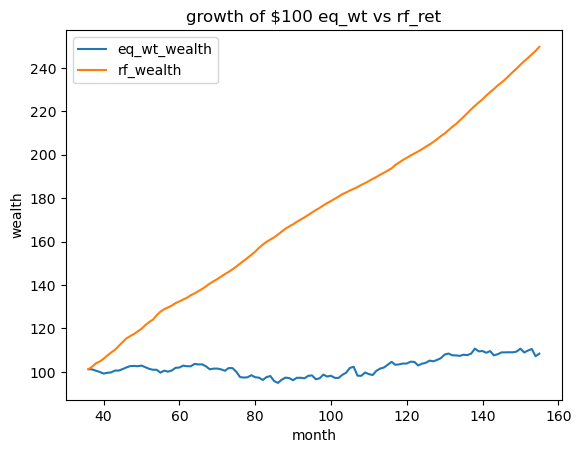

In [ ]:
start_idx = 36
end_idx = 155

eq = size_eq_wt_series.astype(float)
eq_win = eq.loc[(eq.index >= start_idx) & (eq.index <= end_idx)]

mask = eq_win.notna() & rf_ret.notna()
eq_win = eq_win[mask]
rf_win = rf_ret[mask]

wealth_eq = 100.0 * (1.0 + eq_win).cumprod()
wealth_rf = 100.0 * (1.0 + rf_win).cumprod()

wealth_100 = pd.DataFrame({
    "eq_wt_wealth": wealth_eq,
    "rf_wealth": wealth_rf
})

import matplotlib.pyplot as plt
wealth_100.plot()
plt.title("growth of $100 eq_wt vs rf_ret")
plt.ylabel("wealth")
plt.xlabel("month")
plt.show()


## (ii)

In [189]:
price_rel = stk_prices.div(stk_prices.iloc[0])
mcap_t    = price_rel.multiply(init_mkt_cap, axis=1)
mcap_sort = mcap_t.shift(1)  

In [ ]:
mcap_median_t= mcap_sort.median(axis=1, skipna=True)
large_mask = mcap_sort.ge(mcap_median_t, axis=0) & mcap_sort.notna()
small_mask = mcap_sort.lt(mcap_median_t, axis=0) & mcap_sort.notna()

large_signal = mom_12_1.where(large_mask)
small_signal = mom_12_1.where(small_mask)

large_ranks = large_signal.rank(pct=True, axis=1, method="average")
small_ranks = small_signal.rank(pct=True, axis=1, method="average")

large_long_mask  = large_ranks > 0.80
large_short_mask = large_ranks <= 0.20
small_long_mask  = small_ranks > 0.80
small_short_mask = small_ranks <= 0.20

n_large_long  = large_long_mask.sum(axis=1)
n_large_short = large_short_mask.sum(axis=1)
n_small_long  = small_long_mask.sum(axis=1)
n_small_short = small_short_mask.sum(axis=1)

w_large_long  = large_long_mask.div(n_large_long.replace(0, np.nan), axis=0)
w_large_short = -large_short_mask.div(n_large_short.replace(0, np.nan), axis=0)
w_small_long  = small_long_mask.div(n_small_long.replace(0, np.nan), axis=0)
w_small_short = -small_short_mask.div(n_small_short.replace(0, np.nan), axis=0)

valid_rets = stk_rets.notna()
w_large_long  = w_large_long.where(valid_rets, 0.0)
w_large_short = w_large_short.where(valid_rets, 0.0)
w_small_long  = w_small_long.where(valid_rets, 0.0)
w_small_short = w_small_short.where(valid_rets, 0.0)

w_large = w_large_long.fillna(0.0) + w_large_short.fillna(0.0)
w_small = w_small_long.fillna(0.0) + w_small_short.fillna(0.0)

ret_large = (w_large * stk_rets).sum(axis=1)
ret_small = (w_small * stk_rets).sum(axis=1)

size_eq_wt_series = 0.5 * ret_large + 0.5 * ret_small
size_eq_wt_series.loc[size_eq_wt_series.index[:36]] = np.nan
size_eq_wt_series.name = "size_eq_wt"

size_eq_wt_series.tail(10)

146    0.000016
147    0.000542
148   -0.000247
149    0.003044
150    0.012349
151   -0.015880
152    0.008206
153    0.006574
154   -0.030090
155    0.010854
Name: size_eq_wt, dtype: float64

## (iii)

In [195]:
mcap_median_t = mcap_sort.median(axis=1, skipna=True)
large_mask = mcap_sort.ge(mcap_median_t, axis=0) & mcap_sort.notna()
small_mask = mcap_sort.lt(mcap_median_t, axis=0) & mcap_sort.notna()

large_signal = mom_12_1.where(large_mask)
small_signal = mom_12_1.where(small_mask)

large_ranks = large_signal.rank(pct=True, axis=1, method="average")
small_ranks = small_signal.rank(pct=True, axis=1, method="average")

large_long_mask  = large_ranks > 0.80
large_short_mask = large_ranks <= 0.20
small_long_mask  = small_ranks > 0.80
small_short_mask = small_ranks <= 0.20

valid_rets = stk_rets.notna()

large_long_caps  = mcap_sort.where(large_long_mask)
large_short_caps = mcap_sort.where(large_short_mask)

large_long_w  = large_long_caps.div(large_long_caps.sum(axis=1).replace(0, np.nan), axis=0)
large_short_w = large_short_caps.div(large_short_caps.sum(axis=1).replace(0, np.nan), axis=0) * -1

small_long_caps  = mcap_sort.where(small_long_mask)
small_short_caps = mcap_sort.where(small_short_mask)

small_long_w  = small_long_caps.div(small_long_caps.sum(axis=1).replace(0, np.nan), axis=0)
small_short_w = small_short_caps.div(small_short_caps.sum(axis=1).replace(0, np.nan), axis=0) * -1

large_long_w  = large_long_w.where(valid_rets, 0.0)
large_short_w = large_short_w.where(valid_rets, 0.0)
small_long_w  = small_long_w.where(valid_rets, 0.0)
small_short_w = small_short_w.where(valid_rets, 0.0)

w_large = large_long_w.fillna(0.0) + large_short_w.fillna(0.0)
w_small = small_long_w.fillna(0.0) + small_short_w.fillna(0.0)

ret_large = (w_large * stk_rets).sum(axis=1)
ret_small = (w_small * stk_rets).sum(axis=1)

size_cap_wt_series = 0.5 * ret_large + 0.5 * ret_small
size_cap_wt_series.loc[size_cap_wt_series.index[:36]] = np.nan
size_cap_wt_series.name = "size_cap_wt"

size_cap_wt_series.tail(10)

146    0.003959
147    0.003235
148   -0.007035
149   -0.001821
150    0.013082
151   -0.014547
152    0.001282
153   -0.003596
154   -0.036721
155    0.005102
Name: size_cap_wt, dtype: float64

## (iv)

In [ ]:
mkt_ret = mkt_price.pct_change().reindex(stk_rets.index)
stk_rets.iloc[0] = 0.0
mkt_ret.iloc[0]  = 0.0



excess_stock = stk_rets.sub(rf_ret, axis=0)
excess_mkt   = mkt_ret - rf_ret

window = 36
rm = excess_mkt
rm_df = pd.DataFrame({c: rm for c in stk_rets.columns})

mean_ei  = excess_stock.rolling(window, min_periods=window).mean()
mean_em  = rm_df.rolling(window, min_periods=window).mean()
mean_prod= (excess_stock * rm_df).rolling(window, min_periods=window).mean()
cov_ei_em= mean_prod - (mean_ei * mean_em)

var_em   = (rm_df**2).rolling(window, min_periods=window).mean() - (mean_em**2)
beta_end = cov_ei_em / var_em
beta_t   = beta_end.shift(1)

beta_median_t = beta_t.median(axis=1, skipna=True)
low_beta_mask  = beta_t.lt(beta_median_t, axis=0) & beta_t.notna()
high_beta_mask = beta_t.ge(beta_median_t, axis=0) & beta_t.notna()


low_signal   = mom_12_1.where(low_beta_mask)
high_signal  = mom_12_1.where(high_beta_mask)

low_ranks    = low_signal.rank(pct=True, axis=1, method="average")
high_ranks   = high_signal.rank(pct=True, axis=1, method="average")

low_long_mask    =  low_ranks >  0.80
low_short_mask   =  low_ranks <= 0.20
high_long_mask   = high_ranks >  0.80
high_short_mask  = high_ranks <= 0.20


valid_rets = stk_rets.notna()

low_long_caps  = mcap_sort.where(low_long_mask)
low_short_caps = mcap_sort.where(low_short_mask)

low_long_w  = low_long_caps.div(low_long_caps.sum(axis=1).replace(0, np.nan), axis=0)
low_short_w = low_short_caps.div(low_short_caps.sum(axis=1).replace(0, np.nan), axis=0) * -1

low_long_w  = low_long_w.where(valid_rets, 0.0)
low_short_w = low_short_w.where(valid_rets, 0.0)

w_low = low_long_w.fillna(0.0) + low_short_w.fillna(0.0)


high_long_caps  = mcap_sort.where(high_long_mask)
high_short_caps = mcap_sort.where(high_short_mask)

high_long_w  = high_long_caps.div(high_long_caps.sum(axis=1).replace(0, np.nan), axis=0)
high_short_w = high_short_caps.div(high_short_caps.sum(axis=1).replace(0, np.nan), axis=0) * -1

high_long_w  = high_long_w.where(valid_rets, 0.0)
high_short_w = high_short_w.where(valid_rets, 0.0)

w_high = high_long_w.fillna(0.0) + high_short_w.fillna(0.0)


ret_low  = (w_low  * stk_rets).sum(axis=1)
ret_high = (w_high * stk_rets).sum(axis=1)

beta_cap_wt_series = 0.5 * ret_low + 0.5 * ret_high
beta_cap_wt_series.loc[beta_cap_wt_series.index[:36]] = np.nan
beta_cap_wt_series.name = "beta_cap_wt"


beta_cap_wt_series.tail(10)

146   -0.001360
147    0.001159
148   -0.016994
149    0.003418
150    0.009795
151   -0.027168
152   -0.004623
153   -0.003356
154   -0.042171
155    0.019971
Name: beta_cap_wt, dtype: float64

## (v)

In [204]:
ind_median = pd.DataFrame(index=mom_12_1.index, columns=mom_12_1.columns, dtype=float)

for ind, cols in ind_class.groupby(ind_class).groups.items():
    med = mom_12_1[cols].median(axis=1)
    ind_median.loc[:, cols] = med.values[:, None]

ind_adj = mom_12_1 - ind_median

ranks_adj = ind_adj.rank(pct=True, axis=1, method="average")

long_mask  = ranks_adj > 0.80
short_mask = ranks_adj <= 0.20

n_long  = long_mask.sum(axis=1)
n_short = short_mask.sum(axis=1)

w_long  = long_mask.div(n_long.replace(0, np.nan), axis=0)
w_short = -short_mask.div(n_short.replace(0, np.nan), axis=0)

valid_rets = stk_rets.notna()
w_long  = w_long.where(valid_rets, 0.0)
w_short = w_short.where(valid_rets, 0.0)

weights = w_long.fillna(0.0) + w_short.fillna(0.0)
ind_adj_eq_wt_series = (weights * stk_rets).sum(axis=1)

ind_adj_eq_wt_series.loc[ind_adj_eq_wt_series.index[:36]] = np.nan
ind_adj_eq_wt_series.name = "ind_adj_eq_wt"

ind_adj_eq_wt_series.tail(10)

146   -0.000050
147   -0.001457
148   -0.002343
149    0.007572
150    0.012549
151   -0.013442
152    0.016775
153    0.008474
154   -0.036276
155    0.009595
Name: ind_adj_eq_wt, dtype: float64

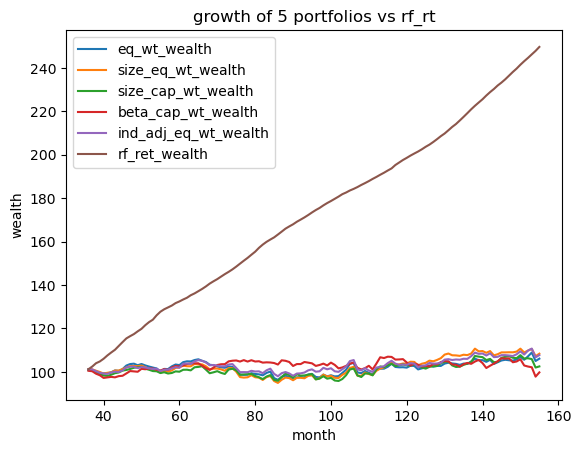

In [208]:
start_idx = 36
end_idx = 155

ports = {
    "eq_wt":         eq_wt_series.astype(float),

    "size_eq_wt":    size_eq_wt_series.astype(float),
    "size_cap_wt":   size_cap_wt_series.astype(float),
    "beta_cap_wt":   beta_cap_wt_series.astype(float),
    "ind_adj_eq_wt": ind_adj_eq_wt_series.astype(float),
}


df = pd.concat(
    [s.loc[(s.index >= start_idx) & (s.index <= end_idx)] for s in ports.values()] + 
    [rf_ret.loc[(rf_ret.index >= start_idx) & (rf_ret.index <= end_idx)].astype(float)],
    axis=1
)
df.columns = list(ports.keys()) + ["rf_ret"]

df = df.dropna(how="any")


wealth = 100.0 * (1.0 + df).cumprod()
wealth.columns = [f"{c}_wealth" for c in wealth.columns]

wealth.plot()
plt.title("growth of 5 portfolios vs rf_rt")
plt.ylabel("wealth")
plt.xlabel("month")
plt.show()


# Part C

    c)	For the n# portfolios in 2b) generate the following set of stats; store the stats below in a python dict, with the first level of keys being the below the stats tag; while the values being a pd.Series object with index being the portfolios tags in step b above.

        i)	Full sample CAGR; compounded annual growth rates (tag: cagr)
        ii)	Full sample annualized volatility (tag: ann_vol)
        iii)	Full Sample Sharpe Ratios (tag: SR);
        iv)	Maximum drawdown for each portfolios (arithmetic drawdown) (tag: drawdown)
        v)	Maximum rolling 36 month SR (tag: max_rolling_sr)


    d)	Store the final output in a nested dict format as below and cache it as a pickle file with name output_dic.pkl

        output_dic = {
            "ret_dict": #return dictionary from step 2b
            "stats_dict": #stats dictionary from step 2c
        }
        pd.to_pickle(output_dic, "output_dic.pkl")

In [227]:
ret_dict = {
    "eq_wt": eq_wt_series,
    "size_eq_wt": size_eq_wt_series,
    "size_cap_wt": size_cap_wt_series,
    "beta_cap_wt": beta_cap_wt_series,
    "ind_adj_eq_wt": ind_adj_eq_wt_series,
}

In [253]:
start_idx = 36
end_idx = 155

stats_cagr = {}
stats_ann_vol = {}
stats_SR = {}
stats_drawdown = {}
stats_max_roll_sr = {}

for tag, r_full in ret_dict.items():

    r_win = r_full.loc[r_full.index[(r_full.index >= start_idx) & (r_full.index <= end_idx)]].astype(float)

    r = r_win.dropna()
    n = len(r)

    rf = rf_ret.reindex(r.index).astype(float)
    ex = r - rf

    # i cagr
    final_wealth = (1.0 + r).prod()
    stats_cagr[tag] = final_wealth**(12.0 / n) - 1.0

    # ii) ann vol
    stats_ann_vol[tag] = r.std(ddof=1) * np.sqrt(12.0)

    # # iii) regular sharpe
    # mu_ex_m = ex.mean()
    # sig_ex_m = ex.std(ddof=1)
    # stats_SR[tag] = (mu_ex_m * 12.0) / (sig_ex_m * np.sqrt(12.0)) if sig_ex_m > 0 else np.nan

    # IMPORTANT!!!
    # iii) sharpe without subtracting risk-free rate because my portfolios are market neutral. Note: my portfolio weights sum to zero, so i did not subtract rf
    mu_m  = r.mean()
    sig_m = r.std(ddof=1)
    stats_SR[tag]  = (mu_m * 12.0) / (sig_m * np.sqrt(12.0)) if sig_m > 0 else np.nan  # Sharpe w/o rf for zero-cost LS

    # iv) amx drawdown
    wealth = (1.0 + r).cumprod()
    peak = wealth.cummax()
    dd = wealth / peak - 1.0
    stats_drawdown[tag] = dd.min()

    # #v) rolling sharp
    # roll_mean = ex.rolling(36, min_periods=36).mean()
    # roll_std  = ex.rolling(36, min_periods=36).std(ddof=1)
    # roll_sr   = (roll_mean * 12.0) / (roll_std * np.sqrt(12.0))
    # roll_sr = roll_sr.replace([np.inf, -np.inf], np.nan)
    # stats_max_roll_sr[tag] = roll_sr.max()

    # IMPORTANT!!!
    #v) rolling sharp same thing here, I just did not subtract rf because my portfolios are market neutral
    roll_mean = r.rolling(36, min_periods=36).mean()
    roll_std  = r.rolling(36, min_periods=36).std(ddof=1)
    roll_SR   = (roll_mean * 12.0) / (roll_std * np.sqrt(12.0))
    stats_max_roll_sr[tag] = roll_SR.replace([np.inf, -np.inf], np.nan).max()


cagr = pd.Series(stats_cagr, name="cagr")
ann_vol = pd.Series(stats_ann_vol, name="ann_vol")
sr = pd.Series(stats_SR, name="SR")
drawdown = pd.Series(stats_drawdown, name="drawdown")
max_rolling_sr= pd.Series(stats_max_roll_sr, name="max_rolling_sr")

stats_dict = {
    "cagr": cagr,
    "ann_vol": ann_vol,
    "SR": sr,
    "drawdown": drawdown,
    "max_rolling_sr": max_rolling_sr,
}

# final output dict
output_dic = {
    "ret_dict": ret_dict,
    "stats_dict": stats_dict,
}

In [252]:
output_dic['stats_dict']['drawdown']

eq_wt           -0.089398
size_eq_wt      -0.084438
size_cap_wt     -0.066219
beta_cap_wt     -0.085800
ind_adj_eq_wt   -0.070317
Name: drawdown, dtype: float64

In [254]:
pd.to_pickle(output_dic, "output_dic.pkl")